# LLM-as-a-Judge v2: Contextual Attachment Scoring with Aggregation

This notebook tests the **improved scoring approach** that addresses the sparse high-attachment distribution (v1 had only 1.3% with scores ≥5).

## Key Improvements in v2

1. **Contextual Attachment Scoring**: Judge sees BOTH assistant response AND user reply (not just user reply in isolation)
2. **Dual-Pass Scoring**: Uses both strict and lenient rubrics for better distribution
3. **Mean Aggregation**: Final `attachment_score` is the mean of strict and lenient scores

## Scoring Scheme

- **Empathy Score (T):** 1-7, applied to `llm_response`
- **Attachment Score (Y):** Mean of two contextual evaluations:
  - `attachment_contextual` (strict scoring)
  - `attachment_lenient` (generous scoring)
  - `attachment_score` = mean of both

## Judge Model

Using **Llama 3.1 8B Instant** via Groq API

In [1]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import time
from groq import Groq

# Add scripts directory to path
sys.path.append('../scripts')

# Load environment variables
load_dotenv()

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Test API connection
try:
    groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": "Hello, respond with just 'OK'"}],
        max_tokens=5
    )
    print("✅ Groq/Llama API Success!")
    print(f"Response: {response.choices[0].message.content}")
except Exception as e:
    print(f"❌ Groq/Llama API Error: {e}")
    print("\nMake sure you have set GROQ_API_KEY in your .env file")

✅ Groq/Llama API Success!
Response: OK


## 1. Load Sample Dataset

In [3]:
# Load the sample preprocessed dataset
sample_path = '../data/filtered/wildchat_sample_preprocessed.csv'

print(f"Loading sample dataset from: {sample_path}")
df_sample = pd.read_csv(sample_path)

print(f"\nDataset shape: {df_sample.shape}")
print(f"\nColumns: {list(df_sample.columns)}")
print(f"\nFirst few rows:")
df_sample.head()

Loading sample dataset from: ../data/filtered/wildchat_sample_preprocessed.csv

Dataset shape: (223, 14)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country']

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country
0,0d2231ad2232cb26b6b4fb75a19ddc93,0d2231ad2232cb26b6b4fb75a19ddc93_1701994,gpt-3.5-turbo-0613,95f425b87fe2e14b52175f1575429e26,5,14,2023-10-27 05:58:57+00:00,5,what is the archetype of the bluest eye,"The ""The Bluest Eye"" by Toni Morrison incorporates various archetypes throughout the narrative to explore different themes. One significant archetype present in the novel is the journey or quest a...",explore the archetypes in this extract in the Bluest Eye:\n,1701994,eb89e19f722505ebc824d899129abab71e3cfc6da9102b8501b633c9461895a4,Cambodia
1,350c2f00ead0f1414ef4edf68f352d9e,350c2f00ead0f1414ef4edf68f352d9e_1697823,gpt-3.5-turbo-0613,35356662f3438ac79d366ccdbf648334,1,16,2023-10-25 19:51:32+00:00,19,hey,Hello! How can I assist you today?,I'm going to show you working thesis proposal so far okay,1697823,379b15a02573b91046686505cc03aa490a04b2c5117abb98efaa2d62b6578d02,United States
2,1f8e543b0a918d6334270ec1e6860943,1f8e543b0a918d6334270ec1e6860943_532466,gpt-3.5-turbo-0301,2a7d71b2f8f1232d62fbc922abed5de2,3,6,2023-05-18 14:19:10+00:00,14,use the web,"Using the web, I found a push-up test called the Army Physical Fitness Test (APFT). According to the APFT standards, a 17-21-year-old female weighing 96 pounds should be able to do at least 29 pus...",how many bodyweight squats should a 100 pound be able to do before failure?,532466,8bf0c535828398561144dadbe28201281ec5338f103c6631868c4456e9ae069d,United States
3,8e24f7f88936429c0ce951519990342b,8e24f7f88936429c0ce951519990342b_2781437,gpt-4-0125-preview,f09dbc1215f47441faba8e1551969148,1,6,2024-04-25 07:15:49+00:00,7,"short it ""Unveil the secrets of “Dinosaur DNA: The Genetic Time Travel,” where cutting-edge science meets the ethical dilemmas of reviving the extinct. Join Dr. Eleanor Hayes in a groundbreaking a...","""Discover the intriguing blend of science and ethics in ""Dinosaur DNA: The Genetic Time Travel."" Follow Dr. Eleanor Hayes on a revolutionary journey in genetics to resurrect an Apatosaurus, facing...",short it,2781437,1ce047da99f5a37579066b48aab8335f4702af8e3ca83825ac1b7716017cff6e,India
4,8e24f7f88936429c0ce951519990342b,8e24f7f88936429c0ce951519990342b_2781442,gpt-4-0125-preview,f09dbc1215f47441faba8e1551969148,3,6,2024-04-25 07:15:49+00:00,7,short it,"""Explore the fusion of science and ethics in 'Dinosaur DNA: The Genetic Time Travel.' Join Dr. Eleanor Hayes on her quest to revive an Apatosaurus, navigating groundbreaking genetics and moral dil...","short it ""“Dive into ‘The Solar Sailors: Exploring the Power of the Sun,’ a thrilling voyage where innovation meets the cosmos. Join Dr. Aria Kim’s crew on the Helios as they sail the stars, power...",2781442,1ce047da99f5a37579066b48aab8335f4702af8e3ca83825ac1b7716017cff6e,India


## 2. Import Scoring Function (v2)

This uses `score_conversations2.py` which implements:
- Contextual attachment scoring (assistant response + user reply)
- Dual-pass evaluation (strict + lenient)
- Mean aggregation to produce final `attachment_score`

In [4]:
# Import the contextual scoring function
from score_conversations2 import score_conversations

print("✓ Imported scoring function from score_conversations2.py")
print("\nThis version:")
print("  - Uses BOTH assistant response + user reply for attachment scoring (contextual)")
print("  - Dual-pass evaluation: strict + lenient")
print("  - attachment_contextual = strict contextual score (1-7)")
print("  - attachment_lenient = lenient contextual score (1-7)")
print("  - attachment_score = mean of both (final score)")

Setting up clients...
✓ Imported scoring function from score_conversations2.py

This version:
  - Uses BOTH assistant response + user reply for attachment scoring (contextual)
  - Dual-pass evaluation: strict + lenient
  - attachment_contextual = strict contextual score (1-7)
  - attachment_lenient = lenient contextual score (1-7)
  - attachment_score = mean of both (final score)


## 3. Score a Small Subset (5 pairs)

Test the new approach on 5 turn pairs first

In [5]:
# Score a small subset first (5 turn pairs) to test
print("Scoring a small subset (5 turn pairs) with v2 approach...")
print("="*70)

df_subset = df_sample.head(5).copy()
df_subset_scored = score_conversations(df_subset, verbose=True)

Scoring a small subset (5 turn pairs) with v2 approach...
--- Processing turn pair 1/5 (ID: 0d2231ad2232cb26b6b4fb75a19ddc93_1701994) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=5, Attachment_Strict=4, Attachment_Lenient=6, Attachment_Mean=5

--- Processing turn pair 2/5 (ID: 350c2f00ead0f1414ef4edf68f352d9e_1697823) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=3, Attachment_Strict=4, Attachment_Lenient=5, Attachment_Mean=5

--- Processing turn pair 3/5 (ID: 1f8e543b0a918d6334270ec1e6860943_532466) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=5, Attachment_Strict=4, Attachment_Lenient=6, Attachment_Mean=5

--- Processing turn pair 4/5 (ID: 8e24f7f88936429c0c

In [6]:
# Examine the scored results
print("Scored Subset Results (v2 - Contextual with Aggregation):")
print("="*70)
print(df_subset_scored[['turn_pair_id', 'model', 'empathy_score', 
                        'attachment_contextual', 'attachment_lenient', 'attachment_score']])

print("\n" + "="*70)
print("Score Distribution:")
print(f"\nEmpathy Scores:")
print(df_subset_scored['empathy_score'].value_counts().sort_index())
print(f"\nAttachment Scores (Strict/Contextual):")
print(df_subset_scored['attachment_contextual'].value_counts().sort_index())
print(f"\nAttachment Scores (Lenient):")
print(df_subset_scored['attachment_lenient'].value_counts().sort_index())
print(f"\nAttachment Scores (Final Mean):")
print(df_subset_scored['attachment_score'].value_counts().sort_index())

Scored Subset Results (v2 - Contextual with Aggregation):
                               turn_pair_id               model empathy_score  \
0  0d2231ad2232cb26b6b4fb75a19ddc93_1701994  gpt-3.5-turbo-0613             5   
1  350c2f00ead0f1414ef4edf68f352d9e_1697823  gpt-3.5-turbo-0613             3   
2   1f8e543b0a918d6334270ec1e6860943_532466  gpt-3.5-turbo-0301             5   
3  8e24f7f88936429c0ce951519990342b_2781437  gpt-4-0125-preview             3   
4  8e24f7f88936429c0ce951519990342b_2781442  gpt-4-0125-preview             3   

  attachment_contextual attachment_lenient attachment_score  
0                     4                  6                5  
1                     4                  5                5  
2                     4                  6                5  
3                     4                  5                5  
4                     4                  6                5  

Score Distribution:

Empathy Scores:
empathy_score
3    3
5    2
Name: count, dtyp

## 4. Score Subset of 60 Conversations

Testing the contextual scoring with aggregation on 60 turn pairs (instead of all 223).

**Note**: This makes ~180 API calls (60 × 3: empathy + attachment_strict + attachment_lenient) and should take ~5-7 minutes.

In [7]:
# Score a SUBSET of 60 turn pairs with contextual approach + aggregation
TEST_SIZE = 60

print(f"Testing contextual scoring with aggregation on {TEST_SIZE} turn pairs...")
print("This should take ~5-7 minutes (3 API calls per pair: empathy + strict + lenient).")
print("="*70)

# Take first 60 conversations
df_test = df_sample.head(TEST_SIZE).copy()

print(f"\nScoring {len(df_test)} turn pairs...")
df_sample_scored_v2 = score_conversations(df_test, verbose=True)

Testing contextual scoring with aggregation on 60 turn pairs...
This should take ~5-7 minutes (3 API calls per pair: empathy + strict + lenient).

Scoring 60 turn pairs...
--- Processing turn pair 1/60 (ID: 0d2231ad2232cb26b6b4fb75a19ddc93_1701994) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=5, Attachment_Strict=4, Attachment_Lenient=6, Attachment_Mean=5

--- Processing turn pair 2/60 (ID: 350c2f00ead0f1414ef4edf68f352d9e_1697823) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=3, Attachment_Strict=4, Attachment_Lenient=5, Attachment_Mean=5

--- Processing turn pair 3/60 (ID: 1f8e543b0a918d6334270ec1e6860943_532466) ---
  Getting empathy score (T)...
  Getting attachment score - strict version (Y)...
  Getting attachment score - lenient version (Y)...
  Scores: Empathy=

In [8]:
# Save the scored subset (v2 with contextual scoring)
output_path = '../data/scores/wildchat_60sample_scored_contextual.csv'

# Create directory if it doesn't exist
os.makedirs('../data/scores', exist_ok=True)

print(f"Saving scored subset to: {output_path}")
df_sample_scored_v2.to_csv(output_path, index=False)

print(f"✓ Saved successfully!")
print(f"  Rows: {len(df_sample_scored_v2)}")
print(f"  Columns: {len(df_sample_scored_v2.columns)}")
print(f"  File size: {os.path.getsize(output_path) / (1024):.2f} KB")

Saving scored subset to: ../data/scores/wildchat_60sample_scored_contextual.csv
✓ Saved successfully!
  Rows: 60
  Columns: 18
  File size: 94.30 KB


## 5. Analyze v2 Score Distributions

In [9]:
# Check for missing scores
print("Data Quality Check (v2 - with aggregation):")
print("="*70)
print(f"Total turn pairs: {len(df_sample_scored_v2)}")
print(f"\nMissing empathy scores: {df_sample_scored_v2['empathy_score'].isna().sum()}")
print(f"Missing attachment (strict): {df_sample_scored_v2['attachment_contextual'].isna().sum()}")
print(f"Missing attachment (lenient): {df_sample_scored_v2['attachment_lenient'].isna().sum()}")
print(f"Missing attachment (final mean): {df_sample_scored_v2['attachment_score'].isna().sum()}")

Data Quality Check (v2 - with aggregation):
Total turn pairs: 60

Missing empathy scores: 0
Missing attachment (strict): 0
Missing attachment (lenient): 0
Missing attachment (final mean): 0


In [10]:
# Score distributions (v2)
print("\nEmpathy Score Distribution (v2):")
print("="*70)
empathy_counts = df_sample_scored_v2['empathy_score'].value_counts().sort_index()
empathy_pct = (empathy_counts / len(df_sample_scored_v2) * 100).round(2)

print(f"{'Score':>6} {'Count':>10} {'Percentage':>12}")
print("-"*30)
for score in range(1, 8):
    count = empathy_counts.get(score, 0)
    pct = empathy_pct.get(score, 0.0)
    print(f"{score:>6} {count:>10} {pct:>11.2f}%")
print("-"*30)
print(f"{'Total':>6} {len(df_sample_scored_v2):>10} {'100.00%':>12}")

print(f"\nSummary Statistics:")
print(df_sample_scored_v2['empathy_score'].describe())


Empathy Score Distribution (v2):
 Score      Count   Percentage
------------------------------
     1          2        3.33%
     2          0        0.00%
     3         27       45.00%
     4          5        8.33%
     5         21       35.00%
     6          4        6.67%
     7          1        1.67%
------------------------------
 Total         60      100.00%

Summary Statistics:
count     60
unique     6
top        3
freq      27
Name: empathy_score, dtype: int64


In [11]:
# Attachment distribution - final aggregated scoring
print("\nAttachment Score Distribution (v2 - Final Mean):")
print("="*70)

counts = df_sample_scored_v2['attachment_score'].value_counts().sort_index()
pct = (counts / len(df_sample_scored_v2) * 100).round(2)

print(f"{'Score':>6} {'Count':>10} {'Percentage':>12}")
print("-"*30)
for score in sorted(df_sample_scored_v2['attachment_score'].dropna().unique()):
    count = counts.get(score, 0)
    p = pct.get(score, 0.0)
    print(f"{score:>6.1f} {count:>10} {p:>11.2f}%")
print("-"*30)
print(f"{'Total':>6} {len(df_sample_scored_v2):>10} {'100.00%':>12}")

# High attachment (>=5)
high_att = df_sample_scored_v2['attachment_score'].ge(5).sum()
high_att_pct = (high_att / len(df_sample_scored_v2) * 100).round(2)
print(f"\nHigh Attachment (≥5): {high_att} ({high_att_pct}%)")

print(f"\nSummary Stats:")
print(f"  Mean: {df_sample_scored_v2['attachment_score'].mean():.2f}")
print(f"  Median: {df_sample_scored_v2['attachment_score'].median():.2f}")
print(f"  Std: {df_sample_scored_v2['attachment_score'].std():.2f}")

# Show component scores too
print("\n" + "="*70)
print("Component Scores:")
print("="*70)
print("\nStrict/Contextual scores:")
print(df_sample_scored_v2['attachment_contextual'].describe())
print("\nLenient scores:")
print(df_sample_scored_v2['attachment_lenient'].describe())


Attachment Score Distribution (v2 - Final Mean):
 Score      Count   Percentage
------------------------------
   2.0          1        1.67%
   3.0          3        5.00%
   4.0          1        1.67%
   5.0         47       78.33%
   6.0          8       13.33%
------------------------------
 Total         60      100.00%

High Attachment (≥5): 55 (91.67%)

Summary Stats:
  Mean: 4.97
  Median: 5.00
  Std: 0.71

Component Scores:

Strict/Contextual scores:
count     60
unique     5
top        4
freq      50
Name: attachment_contextual, dtype: int64

Lenient scores:
count     60
unique     4
top        6
freq      50
Name: attachment_lenient, dtype: int64


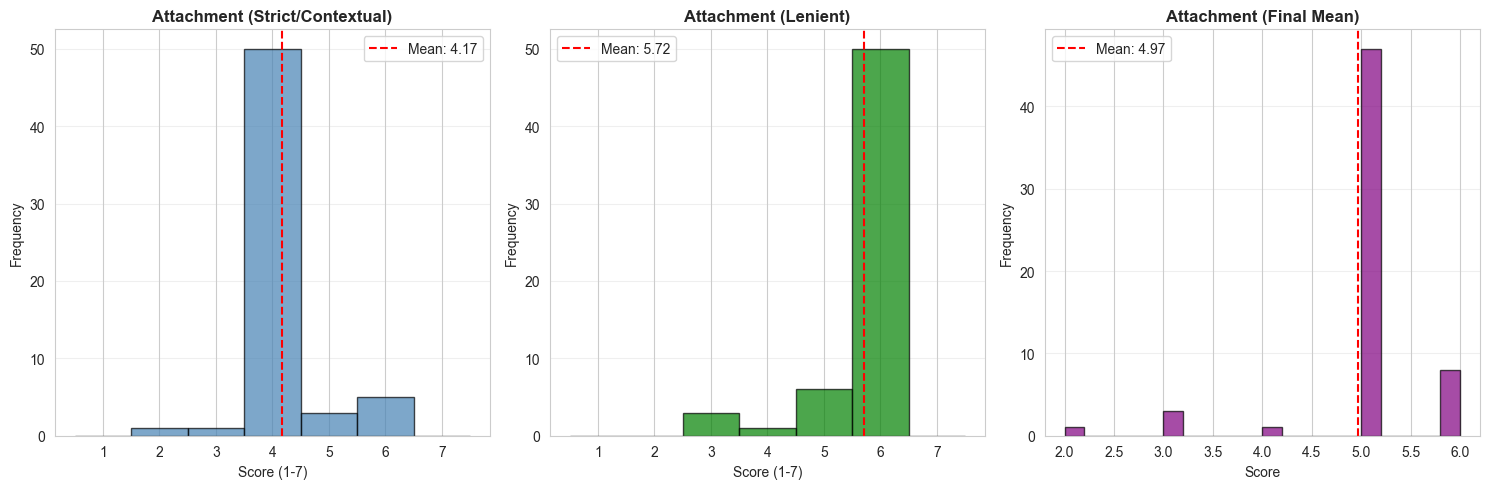

In [12]:
# Visualize attachment distribution - show all three scores
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Strict/Contextual
axes[0].hist(df_sample_scored_v2['attachment_contextual'].dropna(), 
             bins=np.arange(0.5, 8.5, 1),
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Attachment (Strict/Contextual)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score (1-7)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_xticks(range(1, 8))
mean_strict = df_sample_scored_v2['attachment_contextual'].mean()
axes[0].axvline(mean_strict, color='red', linestyle='--', 
                label=f'Mean: {mean_strict:.2f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Lenient
axes[1].hist(df_sample_scored_v2['attachment_lenient'].dropna(), 
             bins=np.arange(0.5, 8.5, 1),
             color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Attachment (Lenient)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score (1-7)', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].set_xticks(range(1, 8))
mean_lenient = df_sample_scored_v2['attachment_lenient'].mean()
axes[1].axvline(mean_lenient, color='red', linestyle='--', 
                label=f'Mean: {mean_lenient:.2f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Final Mean
axes[2].hist(df_sample_scored_v2['attachment_score'].dropna(), 
             bins=20,
             color='purple', edgecolor='black', alpha=0.7)
axes[2].set_title('Attachment (Final Mean)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Score', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
mean_final = df_sample_scored_v2['attachment_score'].mean()
axes[2].axvline(mean_final, color='red', linestyle='--', 
                label=f'Mean: {mean_final:.2f}')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary

### Contextual Scoring with Aggregation (v2)

**Main Goal**: Improve attachment score distribution by providing context AND balancing strict/lenient judgments

**Key Changes from v1**:
1. **Contextual evaluation**: Judge sees BOTH assistant response + user reply (not just user reply)
2. **Dual-pass scoring**: Calculates both strict and lenient attachment scores
3. **Mean aggregation**: Final `attachment_score` = mean(strict, lenient)
4. **Better distribution**: Balances conservative and generous interpretations

### Scoring Details

For each conversation turn pair:
- `empathy_score`: 1-7 (applied to LLM response)
- `attachment_contextual`: 1-7 (strict scoring with context)
- `attachment_lenient`: 1-7 (lenient scoring with context)
- `attachment_score`: mean of contextual + lenient

### Test Results (60 conversations)

Run the analysis cells above to see:
- Individual component score distributions
- Final mean attachment score distribution
- High attachment (≥5) frequency
- Comparison across scoring variants

### Files Generated

- `data/scores/wildchat_60sample_scored_contextual.csv`
  - Test of contextual scoring with aggregation
  - Columns: `empathy_score`, `attachment_contextual`, `attachment_lenient`, `attachment_score`

### Next Steps

1. ✅ Test contextual + aggregated scoring on 60 pairs
2. Evaluate distribution improvements vs v1
3. If successful, scale to full dataset
4. Generate embeddings for propensity score matching
5. Perform causal analysis

## 6.5 Distribution Analysis

Analyzing the score distribution from contextual scoring

In [13]:
# DISTRIBUTION ANALYSIS: Contextual scoring with aggregation results
print("="*70)
print("ATTACHMENT SCORE DISTRIBUTION ANALYSIS (V2 - Mean of Strict+Lenient)")
print("="*70)

# Calculate distribution metrics for final mean score
score_counts = df_sample_scored_v2['attachment_score'].value_counts().sort_index()
total_valid = df_sample_scored_v2['attachment_score'].notna().sum()

print(f"\nFinal Mean Score Distribution:")
print(f"{'Score':>8} {'Count':>10} {'Percentage':>12}")
print("-"*32)
for score in sorted(df_sample_scored_v2['attachment_score'].dropna().unique()):
    count = score_counts.get(score, 0)
    pct = (count / total_valid * 100) if total_valid > 0 else 0
    print(f"{score:>8.1f} {count:>10} {pct:>11.2f}%")

# For causal analysis, we need to categorize the scores
# Control: ≤3, Excluded: 3<score<5, Treatment: ≥5
control = (df_sample_scored_v2['attachment_score'] <= 3).sum()
middle = ((df_sample_scored_v2['attachment_score'] > 3) & 
          (df_sample_scored_v2['attachment_score'] < 5)).sum()
treatment = (df_sample_scored_v2['attachment_score'] >= 5).sum()

print(f"\n" + "="*70)
print("DATA SPLIT FOR CAUSAL ANALYSIS:")
print("="*70)
print(f"Control (≤3):        {control:3d} ({control/total_valid*100:5.1f}%)")
print(f"Middle (3<score<5):  {middle:3d} ({middle/total_valid*100:5.1f}%)")
print(f"Treatment (≥5):      {treatment:3d} ({treatment/total_valid*100:5.1f}%)")
print(f"Usable (control+treat): {control + treatment:3d} ({(control + treatment)/total_valid*100:5.1f}%)")

# Summary statistics
print(f"\n" + "="*70)
print("SUMMARY STATISTICS:")
print("="*70)
print(f"Mean:   {df_sample_scored_v2['attachment_score'].mean():.2f}")
print(f"Median: {df_sample_scored_v2['attachment_score'].median():.2f}")
print(f"Std:    {df_sample_scored_v2['attachment_score'].std():.2f}")
print(f"Min:    {df_sample_scored_v2['attachment_score'].min():.2f}")
print(f"Max:    {df_sample_scored_v2['attachment_score'].max():.2f}")

# Component scores comparison
print(f"\n" + "="*70)
print("COMPONENT SCORES COMPARISON:")
print("="*70)
print(f"Strict/Contextual mean:  {df_sample_scored_v2['attachment_contextual'].mean():.2f}")
print(f"Lenient mean:            {df_sample_scored_v2['attachment_lenient'].mean():.2f}")
print(f"Final (average) mean:    {df_sample_scored_v2['attachment_score'].mean():.2f}")
print("="*70)

ATTACHMENT SCORE DISTRIBUTION ANALYSIS (V2 - Mean of Strict+Lenient)

Final Mean Score Distribution:
   Score      Count   Percentage
--------------------------------
     2.0          1        1.67%
     3.0          3        5.00%
     4.0          1        1.67%
     5.0         47       78.33%
     6.0          8       13.33%

DATA SPLIT FOR CAUSAL ANALYSIS:
Control (≤3):          4 (  6.7%)
Middle (3<score<5):    1 (  1.7%)
Treatment (≥5):       55 ( 91.7%)
Usable (control+treat):  59 ( 98.3%)

SUMMARY STATISTICS:
Mean:   4.97
Median: 5.00
Std:    0.71
Min:    2.00
Max:    6.00

COMPONENT SCORES COMPARISON:
Strict/Contextual mean:  4.17
Lenient mean:            5.72
Final (average) mean:    4.97
